|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Overfitting, cross-validation, regularization<h1>|
|<h2>Lecture:</h2>|<h1><b>Cross-validation on regression<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# new!
from torch.utils.data import DataLoader

# Create the data and the model

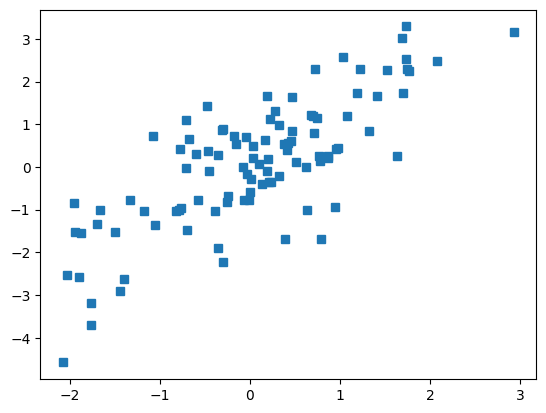

In [40]:
N = 100
x = torch.randn(N,1)
y = x + torch.randn(N,1)

# and plot
plt.plot(x,y,'s')
plt.show()

In [3]:
# build model
ANNreg = nn.Sequential(
    nn.Linear(1,1),  # input layer
    nn.ReLU(),       # activation function
    nn.Linear(1,1)   # output layer
    )

In [36]:
# model meta-parameters

learningRate = .05

# loss function
lossfun = nn.MSELoss()

# optimizer
optimizer = torch.optim.SGD(ANNreg.parameters(),lr=learningRate)

# Select data for training

In [41]:
# select training data (note the hard-coded N!)
# trainidx  = np.random.choice(range(N),int(.8 * N),replace=False) # random indices
# trainBool = np.zeros(N,dtype=bool) # initialize vector of Falses'
# trainBool[trainidx] = True # set selected samples to True

# show the sizes
print(f'N = {N}')
# print(x[trainBool].shape)
# print(x[~trainBool].shape)

# use scikitlearn to split the data
train_data,test_data, train_labels,test_labels = \
                              train_test_split(x, y, train_size=.8)
                              
# then convert them into PyTorch Datasets (note: already converted to tensors)
train_data = torch.utils.data.TensorDataset(train_data,train_labels)
test_data  = torch.utils.data.TensorDataset(test_data,test_labels)
print('train_data:', train_data.tensors[0].shape)
print('test_data:', test_data.tensors[0].shape)

# finally, translate into dataloader objects
train_loader = DataLoader(train_data,shuffle=True,batch_size=12)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

N = 100
train_data: torch.Size([80, 1])
test_data: torch.Size([20, 1])


# Train the model

In [80]:
numepochs = 250

trainBatchLoss = []
trainLoss = []
testLoss = []
for epochi in range(numepochs):

  for x_train,y_train in train_loader:
    # forward pass
    predYtrain = ANNreg(x_train)

    # compute loss
    loss = lossfun(predYtrain,y_train)
    trainBatchLoss.append(loss.item())

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
  trainLoss.append(np.mean(trainBatchLoss))
  
  x_test,y_test = next(iter(test_loader)) # extract X,y from test dataloader
  predYtest = torch.argmax( ANNreg(x_test),axis=1 )
  testLoss.append((predYtest - y_test).pow(2).mean().item())

In [7]:
# report the losses

# compute losses of the TEST set
# predYtest = ANNreg(x[~trainBool])
# testloss = (predYtest-y[~trainBool]).pow(2).mean()

# x_test,y_test = next(iter(test_loader)) # extract X,y from test dataloader
# predYtest = torch.argmax( ANNreg(x_test),axis=1 )
# testLoss = (predYtest-y_test).pow(2).mean()

# print out final TRAIN loss and TEST loss
# print(f'Final TRAIN loss: {loss.detach():.2f}')
# print(f'Final TEST loss: {testLoss.detach():.2f}')

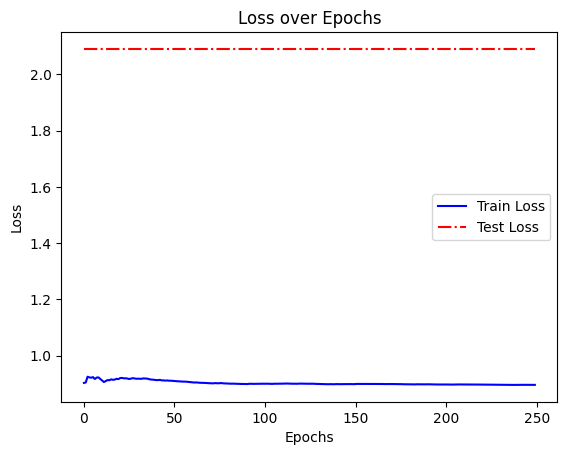

In [61]:
fig = plt.figure()
plt.plot(trainLoss,'b-',label='Train Loss')
plt.plot(testLoss,'r-.',label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

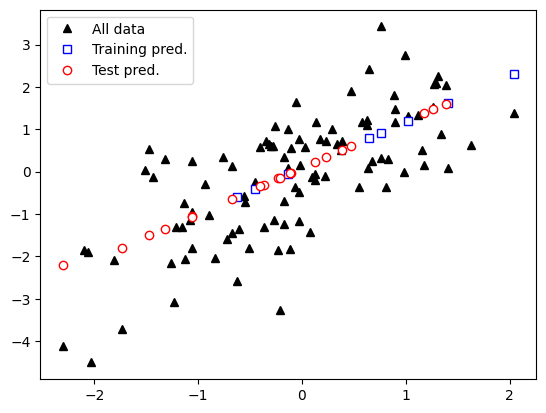

In [27]:
### plot the data

# predictions for final training run
predYtrain = ANNreg(x_train).detach().numpy()
predYtest = ANNreg(x_test).detach().numpy()

# now plot
plt.plot(x,y,'k^',label='All data')
plt.plot(x_train, predYtrain,
         'bs',markerfacecolor='w',label='Training pred.')
plt.plot(x_test, predYtest,
         'ro',markerfacecolor='w',label='Test pred.')
plt.legend()
plt.show()

# Additional explorations

In [ ]:
# 1) The train/test split is currently hard-coded to be 80/20 (note the number "80"). This is bad coding style, because
#    if you change the number of datapoints from N=100 to N=10000, then we're still only training on 80 samples and testing
#    on 10000-80=9920 samples. Change how the variable trainBool is created so that it always trains on 80% of the data,
#    regardless of the dataset size.
#
# 2) Re-write this code to use scikitlearn and/or DataLoader instead of manually separating the data into train/test.
#
# 3) Do we really need 500 epochs to train the model? To find out, add code to the training loop to compute the MSEloss
#    for the train and test data on each iteration during training. Then plot the train and test error as a function of
#    training epoch. What is your evaluation of an appropriate amount of training for this model/dataset?
#
# No, 250 epochs is enough.
#